In [29]:
import importlib
import plots
importlib.reload(plots)

import pandas as pd
from typing import List, Dict, Tuple, Optional
import os
import numpy as np
import matplotlib.pyplot as plt
from plots import *

In [2]:
run_name="mining2"
output_dir = f"../plots/{run_name}"
os.makedirs(output_dir,exist_ok=True)

In [3]:
df = pd.read_csv("../data/ait_ads/combined_ait_labeled.csv", low_memory=False)
df.columns

# make sure timestamps are datetime and sorted
df = df.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)
df = df.dropna(subset=["timestamp"]).sort_values("timestamp")

### Normalize `category`

In [4]:
df["category_norm"] = df["category"].astype(str).str.split(" - ").str[0].str.strip()

### Make time windows

In [5]:
from typing import List, Tuple, Optional
import pandas as pd

def make_time_windows(
    t: pd.Series,
    window_size: str = "3D",   # "3D", "12H", "6H"
    step_size: str = "3D",     # "1D", "6H"
    start: Optional[pd.Timestamp] = None,
    end: Optional[pd.Timestamp] = None,
    align_to: Optional[str] = "D",  # "D" for day, "H" for hour, or None. Rounds start and end times to clean boundaries before generating windows
    tz: str = "UTC",
) -> List[Tuple[pd.Timestamp, pd.Timestamp]]:
    """
    Returns list of (start_k, end_k) timestamps for half-open windows [start, end).
    """

    if start is None:
        start = t.min()
    if end is None:
        end = t.max()

    start = pd.Timestamp(start).tz_convert(tz)
    end = pd.Timestamp(end).tz_convert(tz)

    # Optional alignment
    if align_to is not None:
        start = start.floor(align_to)
        end = end.ceil(align_to)

    win = pd.Timedelta(window_size)
    step = pd.Timedelta(step_size)

    windows = []
    cur = start

    while cur < end:
        windows.append((cur, cur + win))
        cur += step

    return windows


## Tokenize alerts

In [6]:
def tokenize_alerts(
    df: pd.DataFrame,
    fields: List[str],
    source_col: str = "source",          # e.g. "aminer" / "wazuh"
    add_source_prefix: bool = True,
    null_token: str = "<NA>",
    max_unique_per_field: int = 5000,    # guardrail against explosions (IPs, paths, etc.)
) -> pd.Series:
    """
    Returns a Series of list-of-tokens per row.
    Each token is like: "wazuh:rule_level=7" or "aminer:component=ssh".
    """
    # Guardrail: drop fields that don't exist
    fields = [f for f in fields if f in df.columns]

    # Optional: cap high-cardinality fields to avoid blowing up tokens
    usable_fields = []
    for f in fields:
        nunique = df[f].nunique(dropna=True)
        if nunique <= max_unique_per_field:
            usable_fields.append(f)

    src = df[source_col].fillna("unknown") if source_col in df.columns else pd.Series(["unknown"] * len(df), index=df.index)

    tokens_per_row = []
    for idx, row in df.iterrows():
        row_tokens = []
        src_prefix = f"{row[source_col]}:" if (add_source_prefix and source_col in df.columns) else ""
        for f in usable_fields:
            val = row[f]

                # skip NA and emptry string for some base fields
            if pd.isna(val) or str(val).strip() == "":
                    continue
            if pd.isna(val):
                v = null_token
            else:
                v = str(val).strip()
                if not v:
                    v = null_token
            row_tokens.append(f"{src_prefix}{f}={v}")
        tokens_per_row.append(row_tokens)

    return pd.Series(tokens_per_row, index=df.index)


In [7]:
base_fields = [
    # shared / general
    "source", "scenario",
    "category_norm", "decoder", "decoder_parent",
    "host", "host_ip",
    "proto",

    # wazuh
    "wazuh_level",
    "groups_str",          
    "is_ids_alert",
    "ids_category",
    "ids_severity",
    "mitre_tactic",
    "mitre_technique",

    # aminer
    "aminer_component_type",
    "aminer_training_mode",
    "aminer_new_event",

    # auth/web context flags (already abstracted!)
    "is_auth_event", "is_web_event", "is_cred_event",
    "is_success", "is_uid0",
]

min_support=20


## Mine tokens

In [8]:
def mine_fp_contrast_tokens(
    tokens: pd.Series,          # list-of-tokens per row
    y: pd.Series,               # 0 benign, 1 attack
    top_k: int = 50,
    min_support: int = 200,     # only keep tokens that appear at least this many times overall
    alpha: float = 0.5,         # smoothing for log-odds
) -> pd.DataFrame:
    """
    Returns a dataframe of tokens ranked by how benign-associated they are (label 0).
    Score: smoothed log-odds(token | benign) - log-odds(token | attack)
          = log( (c0+α)/(n0-c0+α) ) - log( (c1+α)/(n1-c1+α) )
    Higher => more benign/FP-associated.
    """
    # Flatten tokens: one row per token ocurrence
    flat = tokens.explode()
    flat_y = y.loc[flat.index]

    # count token occurences for benign vs attack
    n0 = int((flat_y == 0).sum())
    n1 = int((flat_y == 1).sum())


    # Determine probability that an alert is benign given that a certain token X is present in the alert
    # Count token frequency per class
    c0 = flat[flat_y == 0].value_counts()
    c1 = flat[flat_y == 1].value_counts()

    all_tokens = c0.index.union(c1.index)
    c0 = c0.reindex(all_tokens, fill_value=0)
    c1 = c1.reindex(all_tokens, fill_value=0)

    # filter out rarely appearing tokens
    total = c0 + c1
    keep = total[total >= min_support].index
    c0 = c0.loc[keep]
    c1 = c1.loc[keep]
    total = total.loc[keep]

    # Smoothed log-odds contrast score
    # how likely is the token in class benign vs how likely is it in attack
    # positive = token shows up mostly in benign = FP suppression candidate
    # near zero = token appears similarly
    # negative = token is attack-associated
    score = np.log((c0 + alpha) / ((n0 - c0) + alpha)) - np.log((c1 + alpha) / ((n1 - c1) + alpha))

    out = pd.DataFrame({
        "token": c0.index,
        "count_benign": c0.values,
        "count_attack": c1.values,
        "support_total": total.values,
        "score_fp_contrast": score.values,
        "p_benign_given_token": (c0 / (c0 + c1)).values, # p = benign count / (benign + attack)
    }).sort_values("score_fp_contrast", ascending=False)

    # keep only top k tokens
    # return out.head(top_k).reset_index(drop=True)
    return out


## Add behavioural mining (window based)

In [9]:
def add_behavioral_features(df, time_col="timestamp", src_col="srcip", dst_col="dstip"):
    df = df.sort_values(time_col).copy()

    # Source frequency in window
    src_counts = df[src_col].value_counts()
    df["count_src_window"] = df[src_col].map(src_counts)

    # Bin it (important to avoid explosion)
    df["src_freq_bin"] = pd.cut(
        df["count_src_window"],
        bins=[-1, 5, 20, 100, float("inf")],
        labels=["low", "medium", "high", "very_high"]
    )

    # Destination fan-in
    fan_in = df.groupby(dst_col)[src_col].nunique()
    df["unique_src_per_dst"] = df[dst_col].map(fan_in)

    df["dst_fanin_bin"] = pd.cut(
        df["unique_src_per_dst"],
        bins=[-1, 3, 10, 50, float("inf")],
        labels=["low", "medium", "high", "very_high"]
    )

    return df


In [10]:
df_copy = add_behavioral_features(df)

In [22]:
scenario_rankings = dict()
scenario_attack_flags = dict()

for scenario, df_s in df.groupby("scenario", sort=False):
    print(f"running mining for scenario {scenario}....")
    rankings = []
    attack_flags = []
    t_s = df_s["timestamp"]
    windows = make_time_windows(df["timestamp"], window_size="12H", step_size="12H", align_to="h")

    for (start_k, end_k) in windows:
        df_k = df_s[(t_s >= start_k) & (t_s < end_k)]
        if df_k.empty:
            continue

        n_benign = (df_k["y"] == 0).sum()
        n_attack = (df_k["y"] == 1).sum()

        attack_flags.append(n_attack > 0)


        print(f"Window [{start_k}, {end_k})")
        print(f"  Benign alerts : {n_benign}")
        print(f"  Attack alerts : {n_attack}")
        print(f"  Total alerts  : {len(df_k)}")

        
        tokens_k = tokenize_alerts(df_k, base_fields + ["src_freq_bin", "dst_fanin_bin"])
        ranking_k = mine_fp_contrast_tokens(tokens_k, df_k["y"])
        
        rankings.append(ranking_k)
    
    scenario_rankings[scenario] = rankings
    scenario_attack_flags[scenario] = attack_flags


running mining for scenario santos....
Window [2022-01-14 00:00:00+00:00, 2022-01-14 12:00:00+00:00)
  Benign alerts : 15595
  Attack alerts : 0
  Total alerts  : 15595


/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_94838/1220801567.py:30: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  win = pd.Timedelta(window_size)
/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_94838/1220801567.py:31: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  step = pd.Timedelta(step_size)


Window [2022-01-14 12:00:00+00:00, 2022-01-15 00:00:00+00:00)
  Benign alerts : 16461
  Attack alerts : 0
  Total alerts  : 16461
Window [2022-01-15 00:00:00+00:00, 2022-01-15 12:00:00+00:00)
  Benign alerts : 16682
  Attack alerts : 0
  Total alerts  : 16682
Window [2022-01-15 12:00:00+00:00, 2022-01-16 00:00:00+00:00)
  Benign alerts : 15804
  Attack alerts : 0
  Total alerts  : 15804
Window [2022-01-16 00:00:00+00:00, 2022-01-16 12:00:00+00:00)
  Benign alerts : 11844
  Attack alerts : 0
  Total alerts  : 11844
Window [2022-01-16 12:00:00+00:00, 2022-01-17 00:00:00+00:00)
  Benign alerts : 3153
  Attack alerts : 0
  Total alerts  : 3153
Window [2022-01-17 00:00:00+00:00, 2022-01-17 12:00:00+00:00)
  Benign alerts : 3123
  Attack alerts : 40
  Total alerts  : 3163
Window [2022-01-17 12:00:00+00:00, 2022-01-18 00:00:00+00:00)
  Benign alerts : 5753
  Attack alerts : 0
  Total alerts  : 5753
running mining for scenario fox....
Window [2022-01-15 00:00:00+00:00, 2022-01-15 12:00:00+00:0

/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_94838/1220801567.py:30: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  win = pd.Timedelta(window_size)
/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_94838/1220801567.py:31: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  step = pd.Timedelta(step_size)


Window [2022-01-16 00:00:00+00:00, 2022-01-16 12:00:00+00:00)
  Benign alerts : 2368
  Attack alerts : 0
  Total alerts  : 2368
Window [2022-01-16 12:00:00+00:00, 2022-01-17 00:00:00+00:00)
  Benign alerts : 3112
  Attack alerts : 0
  Total alerts  : 3112
Window [2022-01-17 00:00:00+00:00, 2022-01-17 12:00:00+00:00)
  Benign alerts : 1788
  Attack alerts : 2
  Total alerts  : 1790
Window [2022-01-17 12:00:00+00:00, 2022-01-18 00:00:00+00:00)
  Benign alerts : 2053
  Attack alerts : 0
  Total alerts  : 2053
Window [2022-01-18 00:00:00+00:00, 2022-01-18 12:00:00+00:00)
  Benign alerts : 1563
  Attack alerts : 0
  Total alerts  : 1563
Window [2022-01-18 12:00:00+00:00, 2022-01-19 00:00:00+00:00)
  Benign alerts : 4015
  Attack alerts : 81
  Total alerts  : 4096
Window [2022-01-19 00:00:00+00:00, 2022-01-19 12:00:00+00:00)
  Benign alerts : 2360
  Attack alerts : 0
  Total alerts  : 2360
Window [2022-01-19 12:00:00+00:00, 2022-01-20 00:00:00+00:00)
  Benign alerts : 2737
  Attack alerts : 

...

Window [2022-01-26 12:00:00+00:00, 2022-01-27 00:00:00+00:00)
  Benign alerts : 10942
  Attack alerts : 0
  Total alerts  : 10942
Window [2022-01-27 00:00:00+00:00, 2022-01-27 12:00:00+00:00)
  Benign alerts : 11489
  Attack alerts : 0
  Total alerts  : 11489
Window [2022-01-27 12:00:00+00:00, 2022-01-28 00:00:00+00:00)
  Benign alerts : 16570
  Attack alerts : 0
  Total alerts  : 16570
Window [2022-01-28 00:00:00+00:00, 2022-01-28 12:00:00+00:00)
  Benign alerts : 12787
  Attack alerts : 0
  Total alerts  : 12787
Window [2022-01-28 12:00:00+00:00, 2022-01-29 00:00:00+00:00)
  Benign alerts : 14782
  Attack alerts : 0
  Total alerts  : 14782
Window [2022-01-29 00:00:00+00:00, 2022-01-29 12:00:00+00:00)
  Benign alerts : 10264
  Attack alerts : 222
  Total alerts  : 10486
Window [2022-01-29 12:00:00+00:00, 2022-01-30 00:00:00+00:00)
  Benign alerts : 17752
  Attack alerts : 0
  Total alerts  : 17752
Window [2022-01-30 00:00:00+00:00, 2022-01-30 12:00:00+00:00)
  Benign alerts : 15181
  

/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_94838/1220801567.py:30: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  win = pd.Timedelta(window_size)
/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_94838/1220801567.py:31: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  step = pd.Timedelta(step_size)


Window [2022-02-03 12:00:00+00:00, 2022-02-04 00:00:00+00:00)
  Benign alerts : 13592
  Attack alerts : 0
  Total alerts  : 13592
Window [2022-02-04 00:00:00+00:00, 2022-02-04 12:00:00+00:00)
  Benign alerts : 10164
  Attack alerts : 0
  Total alerts  : 10164
Window [2022-02-04 12:00:00+00:00, 2022-02-05 00:00:00+00:00)
  Benign alerts : 13294
  Attack alerts : 0
  Total alerts  : 13294
Window [2022-02-05 00:00:00+00:00, 2022-02-05 12:00:00+00:00)
  Benign alerts : 11782
  Attack alerts : 0
  Total alerts  : 11782
Window [2022-02-05 12:00:00+00:00, 2022-02-06 00:00:00+00:00)
  Benign alerts : 10983
  Attack alerts : 0
  Total alerts  : 10983
Window [2022-02-06 00:00:00+00:00, 2022-02-06 12:00:00+00:00)
  Benign alerts : 10114
  Attack alerts : 0
  Total alerts  : 10114
Window [2022-02-06 12:00:00+00:00, 2022-02-07 00:00:00+00:00)
  Benign alerts : 12632
  Attack alerts : 0
  Total alerts  : 12632
Window [2022-02-07 00:00:00+00:00, 2022-02-07 12:00:00+00:00)
  Benign alerts : 9771
  Att

/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_94838/1220801567.py:30: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  win = pd.Timedelta(window_size)
/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_94838/1220801567.py:31: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  step = pd.Timedelta(step_size)


Window [2022-02-04 12:00:00+00:00, 2022-02-05 00:00:00+00:00)
  Benign alerts : 17623
  Attack alerts : 0
  Total alerts  : 17623
Window [2022-02-05 00:00:00+00:00, 2022-02-05 12:00:00+00:00)
  Benign alerts : 13133
  Attack alerts : 0
  Total alerts  : 13133
Window [2022-02-05 12:00:00+00:00, 2022-02-06 00:00:00+00:00)
  Benign alerts : 15026
  Attack alerts : 0
  Total alerts  : 15026
Window [2022-02-06 00:00:00+00:00, 2022-02-06 12:00:00+00:00)
  Benign alerts : 12895
  Attack alerts : 0
  Total alerts  : 12895
Window [2022-02-06 12:00:00+00:00, 2022-02-07 00:00:00+00:00)
  Benign alerts : 14577
  Attack alerts : 0
  Total alerts  : 14577
Window [2022-02-07 00:00:00+00:00, 2022-02-07 12:00:00+00:00)
  Benign alerts : 14180
  Attack alerts : 0
  Total alerts  : 14180
Window [2022-02-07 12:00:00+00:00, 2022-02-08 00:00:00+00:00)
  Benign alerts : 14986
  Attack alerts : 0
  Total alerts  : 14986
Window [2022-02-08 00:00:00+00:00, 2022-02-08 12:00:00+00:00)
  Benign alerts : 15582
  At

## Heat map for given scenario to show the contrast score of each token over all windows in the scenario

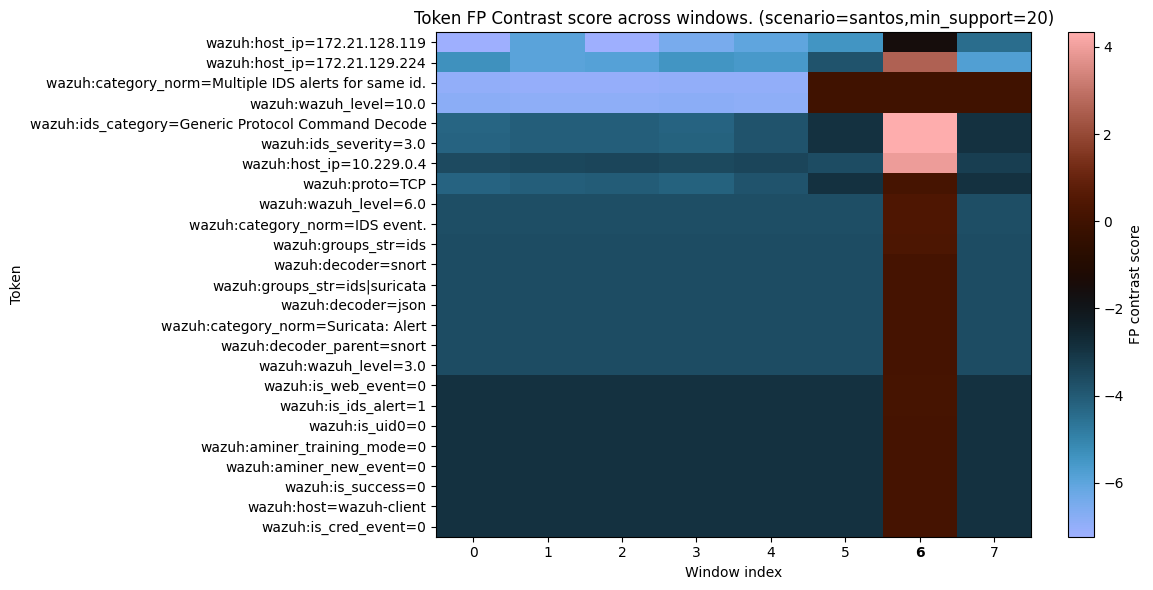

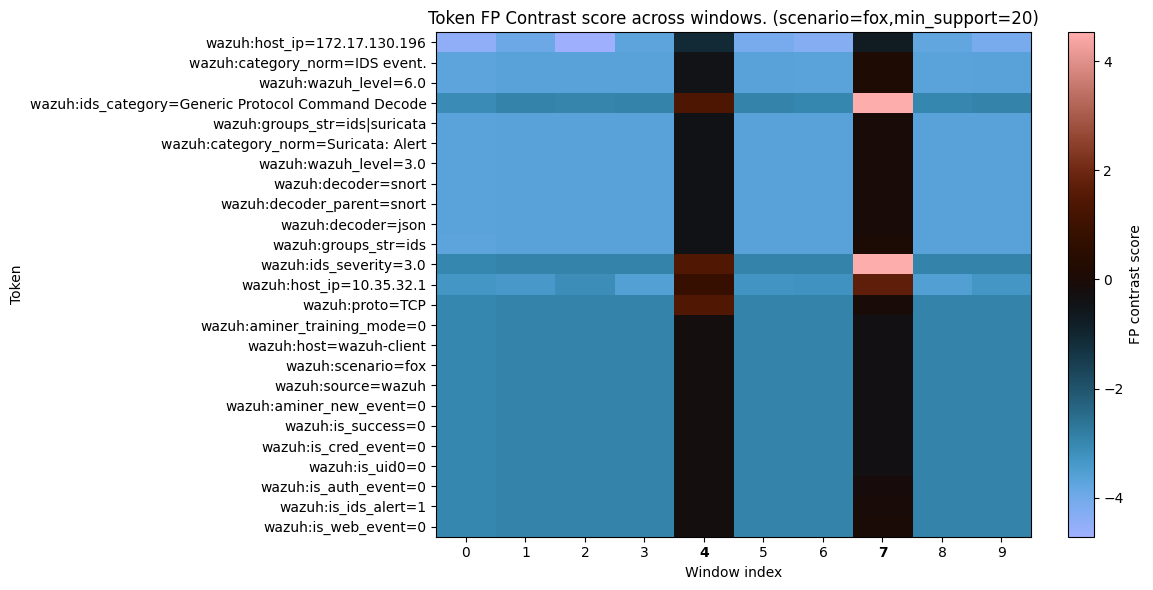

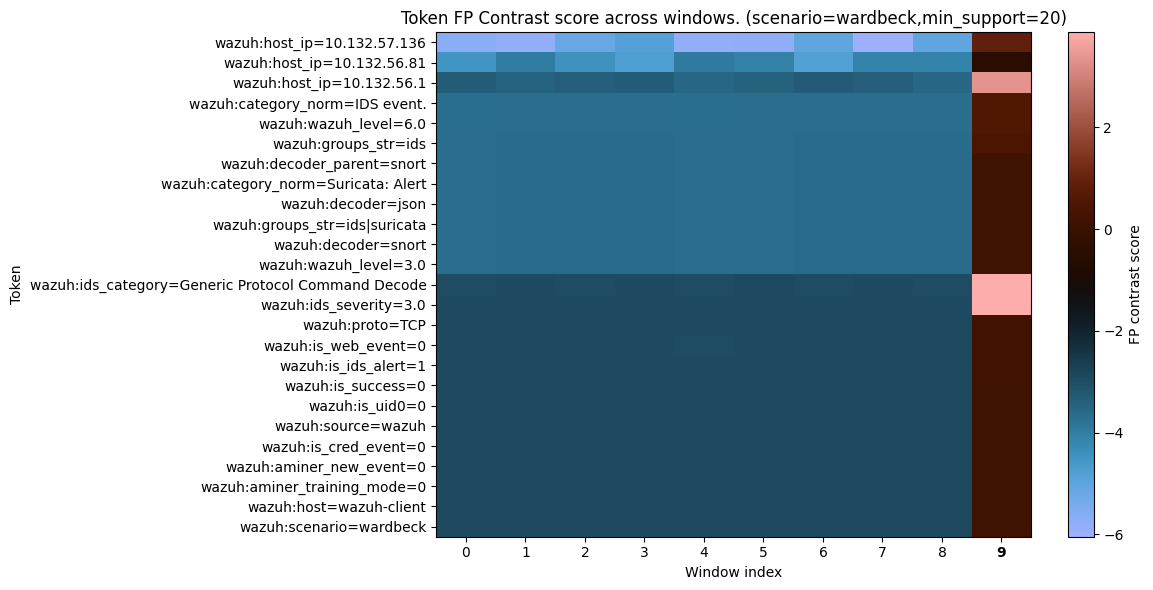

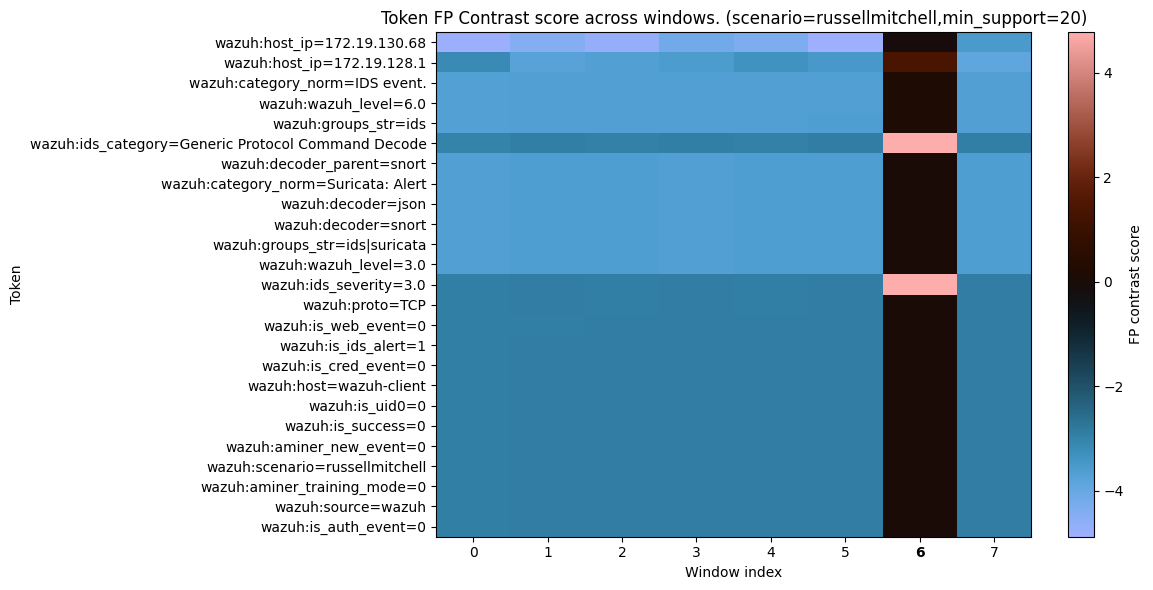

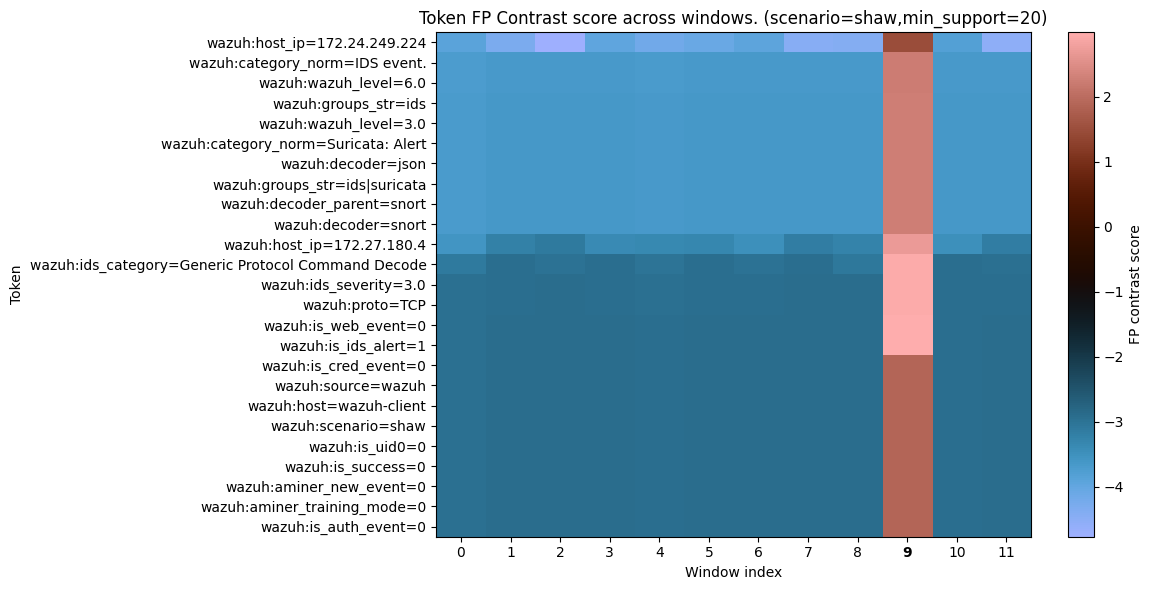

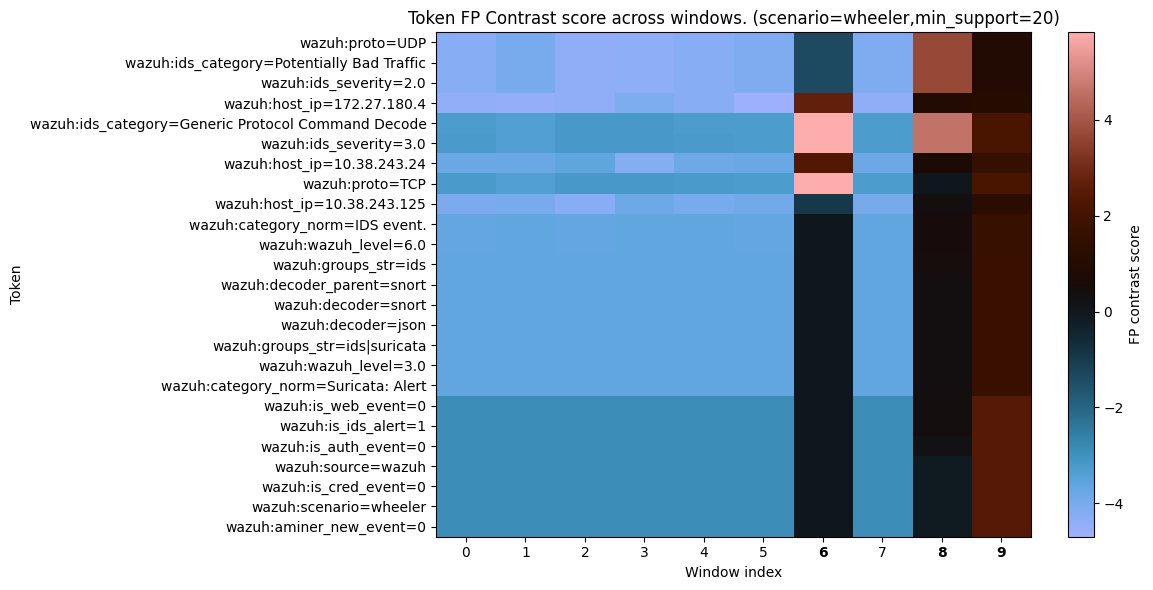

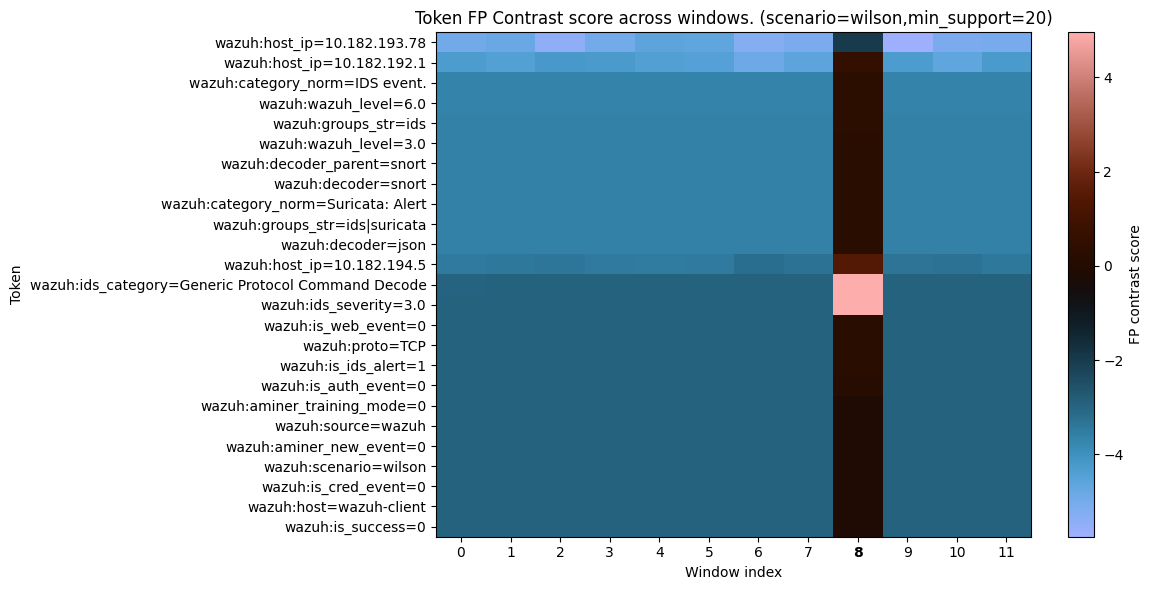

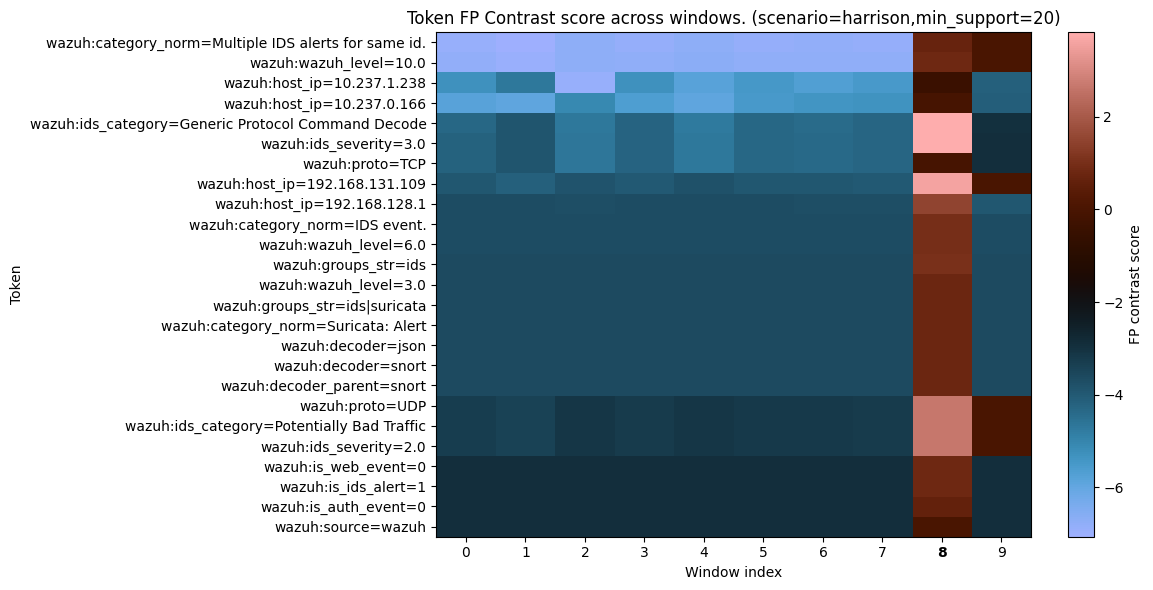

In [30]:
for scenario, df_s in df.groupby("scenario", sort=False):
    rankings = scenario_rankings.get(scenario)
    flags = scenario_attack_flags.get(scenario)
    plot_scenario_heatmap(rankings, flags, output_dir, scenario, min_support)